In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../processed/films_financial.csv")
core = df[df["in_core"]]
print(f"{len(df)} films, {len(core)} in core")

215 films, 58 in core


In [2]:
## step 3 — deflate to constant 2025 dollars (whitepaper 4.1)
## roi and revenue_multiple are within-film ratios so inflation cancels there;
## deflation only matters when comparing ABSOLUTE dollars across years
## (a $5M budget in 2013 is not a $5M budget in 2025)

## annual average US CPI-U (1982-84=100), BLS; 2025-26 are estimates
CPI = {2013: 233.0, 2014: 236.7, 2015: 237.0, 2016: 240.0, 2017: 245.1,
       2018: 251.1, 2019: 255.7, 2020: 258.8, 2021: 271.0, 2022: 292.7,
       2023: 304.7, 2024: 313.7, 2025: 322.0, 2026: 329.0}
BASE_YEAR = 2025

df["deflator"] = df["release_year"].map(lambda y: CPI[BASE_YEAR] / CPI[y])
for col in ["budget_usd", "cost_usd", "studio_revenue_usd", "profit_usd"]:
    df[col.replace("_usd", "_real")] = df[col] * df["deflator"]

core = df[df["in_core"]].copy()
df[["title", "release_year", "budget_usd", "budget_real"]].dropna().head()

,title,release_year,budget_usd,budget_real
0,A Glimpse Inside the Mind of Charles Swan III,2013,12000000.0,1.658369e+07
1,Spring Breakers,2013,5000000.0,6.909871e+06
2,The Bling Ring,2013,15000000.0,2.072961e+07
3,The Spectacular Now,2013,2500000.0,3.454936e+06
4,Enemy,2014,3500000.0,4.761301e+06


In [3]:
## step 5 — quadrant classification (whitepaper 4.5)
## two axes: commercial (multiple >= 1, broke even) x acclaimed (metascore >= 70)

def quadrant(row, multiple_bar=1.0, acclaim_bar=70):
    if pd.isna(row["revenue_multiple"]) or pd.isna(row["metascore"]):
        return None
    hit = row["revenue_multiple"] >= multiple_bar
    acclaimed = row["metascore"] >= acclaim_bar
    if hit and acclaimed:  return "dream"        # art + commerce
    if acclaimed:          return "subsidised"   # prestige that lost money
    if hit:                return "cashcow"      # profit without acclaim
    return "miss"

df["quadrant"] = df.apply(quadrant, axis=1)
core = df[df["in_core"]].copy()
print(core["quadrant"].value_counts())

## sensitivity of the split to the thresholds (whitepaper says report both ways)
for mb, ab in [(2.0, 70), (1.0, 65), (1.0, 75)]:
    q = core.apply(quadrant, axis=1, multiple_bar=mb, acclaim_bar=ab).value_counts()
    print(f"\nmultiple>={mb}, metascore>={ab}: {q.to_dict()}")

quadrant
dream         18
subsidised    18
miss          14
cashcow        7
Name: count, dtype: int64

multiple>=2.0, metascore>=70: {'subsidised': 24, 'miss': 17, 'dream': 12, 'cashcow': 4}

multiple>=1.0, metascore>=65: {'subsidised': 24, 'dream': 21, 'miss': 8, 'cashcow': 4}

multiple>=1.0, metascore>=75: {'miss': 17, 'dream': 15, 'subsidised': 15, 'cashcow': 10}


In [4]:
## step 6 — return distribution moments (whitepaper 6.1, tests H1)
from scipy import stats

for var in ["roi", "log_multiple"]:
    x = core[var].dropna()
    print(f"{var}: n={len(x)} mean={x.mean():.2f} median={x.median():.2f} "
          f"std={x.std():.2f} skew={stats.skew(x):.2f} ex.kurtosis={stats.kurtosis(x):.2f}")

## mean >> median with big positive skew = the venture-capital return shape:
## bounded downside (roi floor at -1), unbounded upside

roi: n=58 mean=1.91 median=-0.10 std=6.67 skew=4.62 ex.kurtosis=23.83
log_multiple: n=58 mean=-0.27 median=-0.11 std=1.91 skew=-1.18 ex.kurtosis=4.10


In [5]:
## step 6 — profit concentration: who carries the fund? (whitepaper 6.1)
## total NET profit can be negative under base assumptions, so shares of the net
## total are meaningless — concentration is measured against total profits EARNED

p = core["profit_real"].dropna().sort_values()
winners = p[p > 0]
n_top = max(1, int(len(p) * 0.10))
top_decile = p.nlargest(n_top)

print(f"profitable films: {len(winners)} of {len(p)}")
print(f"total profits earned:  ${winners.sum()/1e6:,.0f}M")
print(f"total losses:          ${p[p<0].sum()/1e6:,.0f}M")
print(f"net:                   ${p.sum()/1e6:,.0f}M")
print(f"top decile ({n_top} films) = {top_decile.sum()/winners.sum():.0%} of all profits earned")
print(f"top decile titles: {core.loc[top_decile.index, 'title'].tolist()}")

## gini over the winners only (gini is undefined over negative values)
w = winners.sort_values().values
gini_profit = float(np.sum((2*np.arange(1, len(w)+1) - len(w) - 1) * w) / (len(w) * w.sum()))
print(f"gini of positive profits: {gini_profit:.2f}")

profitable films: 25 of 58
total profits earned:  $681M
total losses:          $-718M
net:                   $-37M
top decile (5 films) = 65% of all profits earned
top decile titles: ['Backrooms', 'Hereditary', 'Lady Bird', 'Moonlight', 'Everything Everywhere All at Once']
gini of positive profits: 0.63


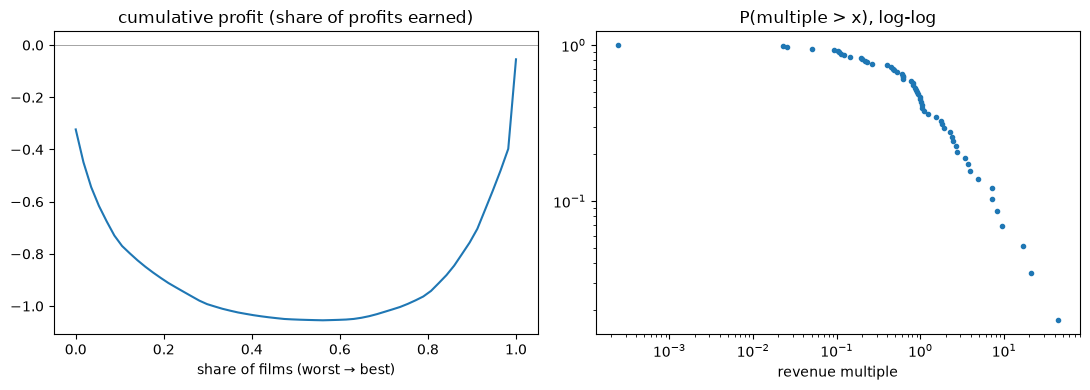

In [6]:
## step 6 — lorenz curve and log-log tail plot (whitepaper 6.1)
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

## lorenz: cumulative share of net profit, films sorted worst to best —
## the curve dips below zero (losses) before the tail pulls it back up
cum = p.cumsum() / p.sum() if p.sum() > 0 else p.cumsum() / winners.sum()
ax1.plot(np.linspace(0, 1, len(p)), p.cumsum().values / winners.sum())
ax1.axhline(0, color="grey", lw=0.5)
ax1.set_title("cumulative profit (share of profits earned)")
ax1.set_xlabel("share of films (worst \u2192 best)")

## survival function of the revenue multiple on log-log axes: an approximately
## straight upper tail is the power-law signature (De Vany & Walls)
m = core["revenue_multiple"].dropna().sort_values(ascending=False)
ax2.loglog(m.values, np.arange(1, len(m)+1) / len(m), marker=".", ls="none")
ax2.set_title("P(multiple > x), log-log")
ax2.set_xlabel("revenue multiple")
plt.tight_layout()
plt.show()

In [7]:
## step 7 — film-level risk/return and the Sharpe-ANALOGUE (whitepaper 6.2)
## films are not sequential returns, so this cross-sectional 'Sharpe' is only an
## analogue (rf = 0); the proper time-series Sharpe is computed on slate years below

sharpe_film = core["roi"].mean() / core["roi"].std()
print(f"film-level: mean roi {core['roi'].mean():.2f}, std {core['roi'].std():.2f}, "
      f"Sharpe-analogue {sharpe_film:.2f}")

## diversification view: where do return and risk live?
by_genre = core.groupby("primary_genre")["roi"].agg(["mean", "std", "count"]).round(2)
print("\nby genre:"); print(by_genre)

core["budget_band"] = pd.cut(core["budget_real"], [0, 5e6, 15e6, np.inf],
                             labels=["<$5M", "$5-15M", ">$15M"])
by_band = core.groupby("budget_band", observed=True)["roi"].agg(["mean", "std", "count"]).round(2)
print("\nby budget band (real):"); print(by_band)

film-level: mean roi 1.91, std 6.67, Sharpe-analogue 0.29

by genre:
               mean    std  count
primary_genre                    
Comedy         5.20  15.29      8
Crime         -0.41    NaN      1
Drama          1.43   2.97     17
Horror         2.91   5.97     17
Other         -0.23   0.63     14
Thriller      -0.98    NaN      1

by budget band (real):
             mean    std  count
budget_band                    
<$5M         5.79  11.22     16
$5-15M       0.98   3.58     24
>$15M       -0.29   0.62     18


In [8]:
## step 7 — year-level slate returns: the 'A24 as a fund' track record (whitepaper 5, 6.2)
## capital-weighted return per release-year cohort; 2026 films are still in release
## so the last complete vintage is 2025

slate = (core[core["release_year"] <= 2025]
         .groupby("release_year")
         .apply(lambda g: pd.Series({
             "n": len(g),
             "capital": g["cost_real"].sum(),
             "profit": g["profit_real"].sum(),
             "slate_return": g["profit_real"].sum() / g["cost_real"].sum()}),
          include_groups=False))

## cumulative 'fund value': compound each vintage in sequence (stylised — vintages
## don't literally roll into each other, but it gives the drawdown picture)
slate["cumulative_fund_value"] = (1 + slate["slate_return"]).cumprod()
peak = slate["cumulative_fund_value"].cummax()
max_drawdown = float(((peak - slate["cumulative_fund_value"]) / peak).max())

## proper time-series Sharpe on annual slate returns; rf = average REAL 3-month
## T-bill 2013-2025, approximately zero over the period
sharpe_year = slate["slate_return"].mean() / slate["slate_return"].std()

print(slate.round(3))
print(f"\ntime-series Sharpe (annual slates): {sharpe_year:.2f}")
print(f"max drawdown of cumulative fund value: {max_drawdown:.0%}")

                 n       capital        profit  slate_return  \
release_year                                                   
2016           2.0  1.408750e+07  4.939724e+07         3.506   
2017           3.0  2.975643e+07  6.195290e+07         2.082   
2018           3.0  2.635245e+07  7.127228e+07         2.705   
2019           5.0  9.743799e+07  3.052301e+07         0.313   
2020           1.0  3.732612e+06 -3.638300e+06        -0.975   
2021           4.0  6.291476e+07 -2.892272e+07        -0.460   
2022           7.0  2.989529e+08 -1.139435e+08        -0.381   
2023           6.0  1.868382e+08 -8.131623e+07        -0.435   
2024           9.0  2.599506e+08 -5.631647e+07        -0.217   
2025          13.0  5.225000e+08 -2.045354e+08        -0.391   

              cumulative_fund_value  
release_year                         
2016                          4.506  
2017                         13.889  
2018                         51.453  
2019                         67.570  
202

In [9]:
## step 7 — downside risk (whitepaper 6.4): variance understates risk when
## returns are skewed, so report the loss-side measures too

roi = core["roi"].dropna()
var_5 = float(np.percentile(roi, 5))
## downside deviation averages min(roi, 0)^2 over ALL films, not just the losers —
## a portfolio where few films lose should score better than one where most do
downside_dev = float(np.sqrt((np.minimum(roi, 0) ** 2).mean()))
sortino = float(roi.mean() / downside_dev)

print(f"empirical VaR: 5% of films return worse than {var_5:.0%} (floor is -100%)")
print(f"share of films that lose money: {(roi < 0).mean():.0%}")
print(f"downside deviation {downside_dev:.2f}, Sortino-analogue {sortino:.2f}")

empirical VaR: 5% of films return worse than -95% (floor is -100%)
share of films that lose money: 57%
downside deviation 0.49, Sortino-analogue 3.92


In [10]:
## step 8 — THE headline test (whitepaper 6.3, H2): does acclaim pay?
## lead with Spearman rank correlation — returns are wildly non-normal, so a
## rank-based measure is more honest than Pearson (reported too, for completeness)

reg = core.dropna(subset=["metascore", "log_multiple"]).copy()
reg = reg[reg["budget_real"] > 0]

rho, rho_p = stats.spearmanr(reg["metascore"], reg["roi"])
r, r_p = stats.pearsonr(reg["metascore"], reg["roi"])
print(f"Spearman metascore vs roi: rho={rho:.3f} (p={rho_p:.3f})   n={len(reg)}")
print(f"Pearson  metascore vs roi: r={r:.3f} (p={r_p:.3f})")

Spearman metascore vs roi: rho=0.316 (p=0.017)   n=57
Pearson  metascore vs roi: r=0.184 (p=0.171)


In [11]:
## step 8 — factor regression (whitepaper 6.3, tests H2 + H3)
## log_multiple as DV (symmetric, tames the tail); robust (HC1) standard errors.
## year dummies omitted: ~13 extra parameters on ~50 observations would overfit —
## the whitepaper's own small-sample caveat. is_original / festival_premiere are
## not yet hand-coded (step-2 leftovers), so the spec is budget + acclaim + genre.
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

def build_X(d):
    X = pd.DataFrame({"ln_budget": np.log(d["budget_real"]), "metascore": d["metascore"]})
    X = X.join(pd.get_dummies(d["primary_genre"], prefix="g", drop_first=True).astype(float))
    return sm.add_constant(X)

X = build_X(reg)
model = sm.OLS(reg["log_multiple"], X).fit(cov_type="HC1")
print(model.summary())

## standardised beta so metascore's size is comparable to the other terms
std_beta = model.params["metascore"] * reg["metascore"].std() / reg["log_multiple"].std()
print(f"\nmetascore: coef={model.params['metascore']:.4f}, p={model.pvalues['metascore']:.3f}, "
      f"standardised beta={std_beta:.3f}")

## multicollinearity check (budget and genre can correlate)
vifs = {c: variance_inflation_factor(X.values, i) for i, c in enumerate(X.columns) if c != "const"}
print("VIF:", {k: round(v, 1) for k, v in vifs.items()})

                            OLS Regression Results                            
Dep. Variable:           log_multiple   R-squared:                       0.464
Model:                            OLS   Adj. R-squared:                  0.388
Method:                 Least Squares   F-statistic:                     794.7
Date:                Sat, 18 Jul 2026   Prob (F-statistic):           5.03e-47
Time:                        20:04:04   Log-Likelihood:                -99.366
No. Observations:                  57   AIC:                             214.7
Df Residuals:                      49   BIC:                             231.1
Df Model:                           7                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.2095      3.211      2.246      0.0

/Users/padraig/Downloads/github-projects/the-slate/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 7, but rank is 6
  warnings.warn('covariance of constraints does not have full '


In [12]:
## step 9 — sensitivity: show the conclusions survive the assumptions (whitepaper 8)
## cost and revenue are pure functions of the assumption dict (same functions as
## financials.ipynb), so a scenario is just a dict swap + re-derive

BASE = {"k_wide": 1.0, "k_platform": 0.5, "r_dom": 0.50, "r_intl": 0.40, "a": 0.5}
SWEEPS = {"k_wide": [0.5, 1.5], "k_platform": [0.3, 0.8],
          "r_dom": [0.45, 0.55], "r_intl": [0.35, 0.45], "a": [0.0, 1.0]}

def compute_cost(row, a):
    k = a["k_wide"] if row["is_wide_release"] else a["k_platform"]
    return row["budget_usd"] * (1 + k)

def compute_revenue(row, a):
    dom, intl, ww = row["domestic_gross_usd"], row["intl_gross_usd"], row["worldwide_gross_usd"]
    if pd.isna(dom) or pd.isna(intl):
        theatrical = ww * (a["r_dom"] + a["r_intl"]) / 2
    else:
        theatrical = dom * a["r_dom"] + max(intl, 0) * a["r_intl"]
    return theatrical * (1 + a["a"])

def run_scenario(assumptions):
    d = core.copy()
    d["cost_s"] = d.apply(compute_cost, axis=1, a=assumptions)
    d["rev_s"] = d.apply(compute_revenue, axis=1, a=assumptions)
    d["roi_s"] = (d["rev_s"] - d["cost_s"]) / d["cost_s"]
    r = d.dropna(subset=["metascore"]).copy()
    r = r[(r["budget_real"] > 0) & (r["rev_s"] > 0)]
    m = sm.OLS(np.log(r["rev_s"] / r["cost_s"]), build_X(r)).fit(cov_type="HC1")
    prof = d["rev_s"] - d["cost_s"]
    winners = prof[prof > 0]
    n_top = max(1, int(prof.notna().sum() * 0.10))
    return {"mean_roi": d["roi_s"].mean(),
            "sharpe": d["roi_s"].mean() / d["roi_s"].std(),
            "beta_metascore": m.params["metascore"],
            "p_metascore": m.pvalues["metascore"],
            "top_decile_share": prof.nlargest(n_top).sum() / winners.sum()}

rows = [{"assumption": "base", "value": np.nan, **run_scenario(BASE)}]
for key, values in SWEEPS.items():
    for v in values:
        rows.append({"assumption": key, "value": v, **run_scenario({**BASE, key: v})})
## corner scenarios (whitepaper 8): if H2 holds in both, the finding is robust
rows.append({"assumption": "conservative", "value": np.nan,
             **run_scenario({"k_wide": 0.5, "k_platform": 0.3, "r_dom": 0.45, "r_intl": 0.35, "a": 0.0})})
rows.append({"assumption": "generous", "value": np.nan,
             **run_scenario({"k_wide": 1.0, "k_platform": 0.5, "r_dom": 0.55, "r_intl": 0.45, "a": 1.0})})

sensitivity = pd.DataFrame(rows).round(3)
print(sensitivity.to_string(index=False))

  assumption  value  mean_roi  sharpe  beta_metascore  p_metascore  top_decile_share
        base    NaN     1.911   0.286           0.047        0.008             0.650
      k_wide   0.50     1.992   0.299           0.046        0.008             0.576
      k_wide   1.50     1.862   0.278           0.047        0.007             0.674
  k_platform   0.30     2.321   0.301           0.047        0.007             0.639
  k_platform   0.80     1.466   0.264           0.046        0.008             0.662
       r_dom   0.45     1.702   0.277           0.047        0.008             0.659
       r_dom   0.55     2.119   0.295           0.047        0.007             0.631
      r_intl   0.35     1.807   0.278           0.047        0.007             0.664
      r_intl   0.45     2.014   0.294           0.047        0.008             0.630
           a   0.00     0.940   0.211           0.047        0.008             0.750
           a   1.00     2.881   0.324           0.047        0.00

In [13]:
## sample robustness (whitepaper 8): do the headline numbers move when the
## dubious rows leave? Backrooms' unverified $190M gross lives in still_in_release

for label, sample in [
    ("core (base)", core),
    ("core excl. still_in_release", core[~core["flag_still_in_release"]]),
    ("core + distribution-only", df[df["budget_usd"].notna() & df["worldwide_gross_usd"].notna()
                                     & ~df["flag_no_budget"] & ~df["flag_no_revenue"]]),
]:
    s = sample.dropna(subset=["roi", "metascore"])
    rho_s, p_s = stats.spearmanr(s["metascore"], s["roi"])   # local names — don't clobber the headline rho
    print(f"{label:<30} n={len(s):>3}  mean roi {s['roi'].mean():>6.2f}  "
          f"median {s['roi'].median():>6.2f}  spearman {rho_s:>6.3f} (p={p_s:.3f})")

core (base)                    n= 57  mean roi   1.96  median  -0.09  spearman  0.316 (p=0.017)
core excl. still_in_release    n= 52  mean roi   1.48  median  -0.10  spearman  0.352 (p=0.011)
core + distribution-only       n=116  mean roi   0.98  median  -0.38  spearman  0.493 (p=0.000)


In [14]:
## step 10 — emit the JSON contract (whitepaper 10): the single handoff to the front end
import json
from datetime import datetime, timezone

def num(v):   # json can't hold NaN / numpy types
    if v is None or (isinstance(v, float) and np.isnan(v)): return None
    return round(float(v), 4)

films_out = []
for _, row in df[df["roi"].notna()].iterrows():
    flags = [f.replace("flag_", "") for f in df.columns if f.startswith("flag_") and row[f]]
    films_out.append({
        "title": row["title"], "year": int(row["release_year"]), "primary_genre": row["primary_genre"],
        "is_original": None, "festival_premiere": None,   # not hand-coded yet
        "budget_real": num(row["budget_real"]), "cost_real": num(row["cost_real"]),
        "studio_revenue_real": num(row["studio_revenue_real"]), "profit_real": num(row["profit_real"]),
        "roi": num(row["roi"]), "revenue_multiple": num(row["revenue_multiple"]),
        "metascore": num(row["metascore"]), "rt_critics": num(row["rt_critics"]),
        "imdb_rating": num(row["imdb_rating"]),
        "quadrant": row["quadrant"] if pd.notna(row["quadrant"]) else None,
        "in_core": bool(row["in_core"]), "flags": flags})

x = core["roi"].dropna()
payload = {
  "meta": {
    "generated_at": datetime.now(timezone.utc).isoformat(),
    "n_films": int(len(core)), "date_range": ["2013", "2025"], "base_year_cpi": BASE_YEAR,
    "assumptions": BASE},
  "films": films_out,
  "distribution": {
    "mean_roi": num(x.mean()), "median_roi": num(x.median()), "std_roi": num(x.std()),
    "skewness": num(stats.skew(x)), "excess_kurtosis": num(stats.kurtosis(x)),
    "gini_profit": num(gini_profit),
    "top_decile_profit_share": num(top_decile.sum() / winners.sum()),
    "lorenz": [[num(i / len(p)), num(c / winners.sum())]
               for i, c in enumerate(p.cumsum(), 1)]},
  "portfolio": {
    "sharpe_analogue_film": num(sharpe_film), "sharpe_timeseries_year": num(sharpe_year),
    "sortino": num(sortino), "var_5pct_roi": num(var_5), "max_drawdown": num(max_drawdown),
    "by_genre": [{"genre": g, "mean_roi": num(v["mean"]), "std_roi": num(v["std"]), "n": int(v["count"])}
                 for g, v in by_genre.iterrows()],
    "by_budget_band": [{"band": str(b), "mean_roi": num(v["mean"]), "std_roi": num(v["std"]), "n": int(v["count"])}
                       for b, v in by_band.iterrows()]},
  "slate_timeseries": [
    {"year": int(y), "n": int(v["n"]), "capital": num(v["capital"]), "profit": num(v["profit"]),
     "slate_return": num(v["slate_return"]), "cumulative_fund_value": num(v["cumulative_fund_value"])}
    for y, v in slate.iterrows()],
  "regression": {
    "dependent": "log_multiple", "n": int(model.nobs), "r_squared": num(model.rsquared),
    "terms": [{"name": t, "coef": num(model.params[t]), "robust_se": num(model.bse[t]),
               "p_value": num(model.pvalues[t]),
               "std_beta": num(model.params[t] * X[t].std() / reg["log_multiple"].std()) if t != "const" else None}
              for t in model.params.index],
    "spearman_acclaim_roi": {"rho": num(rho), "p_value": num(rho_p)},
    "pearson_acclaim_roi": {"r": num(r), "p_value": num(r_p)}},
  "sensitivity": [
    {"assumption": s["assumption"], "value": num(s["value"]), "mean_roi": num(s["mean_roi"]),
     "sharpe": num(s["sharpe"]), "beta_metascore": num(s["beta_metascore"]),
     "p_metascore": num(s["p_metascore"]), "top_decile_share": num(s["top_decile_share"])}
    for _, s in sensitivity.iterrows()]}

with open("../../output/slate.json", "w") as f:
    json.dump(payload, f, indent=2)
print(f"wrote output/slate.json — {len(films_out)} films, "
      f"{len(payload['sensitivity'])} sensitivity scenarios")

wrote output/slate.json — 118 films, 13 sensitivity scenarios
